In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from machineguard.modeling import (
    TARGET_COL,
    FEATURE_COLS,
    NUMERIC_FEATURES,
    build_random_forest_model,
)

In [2]:
DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

X = df[FEATURE_COLS]
y = df[TARGET_COL]

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

In [4]:
random_forest_model = build_random_forest_model()
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('category', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


I want to see which features the random forest used most.

In [5]:
feature_names = random_forest_model.named_steps["preprocessing"].get_feature_names_out()
feature_importance = random_forest_model.named_steps["classifier"].feature_importances_

In [6]:
importance_table = pd.DataFrame({
    "feature":feature_names,
    "importance":feature_importance
}).sort_values("importance", ascending=False)

importance_table

,feature,importance
5,numeric__Rotational speed [rpm],0.307638
6,numeric__Torque [Nm],0.291453
7,numeric__Tool wear [min],0.183578
3,numeric__Air temperature [K],0.120755
4,numeric__Process temperature [K],0.079178
1,category__Type_L,0.006838
2,category__Type_M,0.005962
0,category__Type_H,0.004598


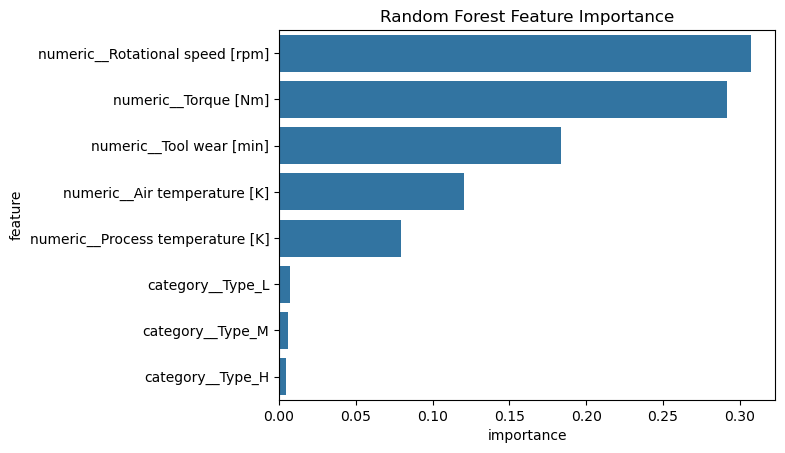

In [7]:
sns.barplot(
    data=importance_table, x="importance", y="feature"
)
plt.title("Random Forest Feature Importance")
plt.show()

- RF gives most importance to rotational speed, torque, tool wear.

## Permutation Importance
- It checks how much the model performance drops when one feature is randomly shuffled.
- If shuffling a feature hurts performance a lot, the model depends on that feature a lot.

In [10]:
perm_result = permutation_importance(
    random_forest_model,
    X_val,
    y_val,
    scoring ='f1',
    n_repeats=10,
    random_state=42
)

In [11]:
permutation_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    'importance_mean':perm_result.importances_mean,
    'importance_std':perm_result.importances_std
})
permutation_table

,feature,importance_mean,importance_std
0,Type,0.049410,0.038124
1,Air temperature [K],0.067588,0.043304
2,Process temperature [K],0.055333,0.036281
3,Rotational speed [rpm],0.289417,0.028234
4,Torque [Nm],0.318937,0.030729
5,Tool wear [min],0.020130,0.025378


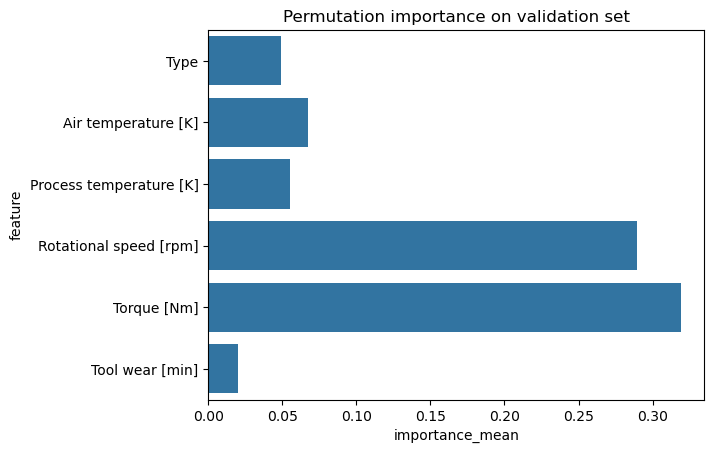

In [12]:
sns.barplot(
    data=permutation_table,
    x="importance_mean",
    y="feature"
)

plt.title("Permutation importance on validation set")
plt.show()

- This shows that torque and rotational speed are the most important features on the val set.
- This means the model depends strongly on load/speed patterns when predicting failure. This also matches the error analysis, where false positives had high torque values.
- Tool wear has lower permutation importance here, so themodel does not rely on it as mush as I first expected